In [ ]:
# !pip install requests rasterio matplotlib numpy tqdm

In [1]:
import requests
import json
import os
import re
import time
import tarfile
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm
from pathlib import Path

# ===================== CONFIGURATION =====================
USGS_USERNAME = "Rishi_677"
USGS_TOKEN = "q2yRNZfo1kp7Z4e@po7GpS7aM!FDN1Hk2j8aRaXkk4rQhVpqrKNC5zgaZxTcke@E"

BASE_URL = "https://m2m.cr.usgs.gov/api/api/json/stable/"

# AOI: ~50 km² area near Madrid, Spain
# Center: ~40.42°N, -3.70°W  |  Box: ~7.07 km x 7.07 km ≈ 50 km²
AOI = {
    "lower_left":  {"latitude": 40.388, "longitude": -3.735},
    "upper_right": {"latitude": 40.452, "longitude": -3.665}
}

DATASET_NAME = "landsat_ot_c2_l2"
MAX_CLOUD_COVER = 20

DOWNLOAD_DIR = os.path.join(os.getcwd(), "landsat_downloads")
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print(f"AOI (Spain - Madrid area):")
print(f"  Lower-Left : {AOI['lower_left']}")
print(f"  Upper-Right: {AOI['upper_right']}")
print(f"Dataset: {DATASET_NAME}")
print(f"Max Cloud Cover: {MAX_CLOUD_COVER}%")
print(f"Download Dir: {DOWNLOAD_DIR}")

AOI (Spain - Madrid area):
  Lower-Left : {'latitude': 40.388, 'longitude': -3.735}
  Upper-Right: {'latitude': 40.452, 'longitude': -3.665}
Dataset: landsat_ot_c2_l2
Max Cloud Cover: 20%
Download Dir: /teamspace/studios/this_studio/Antigravity/landsat_downloads


## 3. M2M API Helper Functions

In [2]:
api_key = None

def m2m_request(endpoint, payload=None):
    """Send a request to the USGS M2M API."""
    url = BASE_URL + endpoint
    headers = {}
    if api_key:
        headers['X-Auth-Token'] = api_key
    
    response = requests.post(url, json=payload, headers=headers)
    
    if response.status_code != 200:
        print(f"  HTTP {response.status_code} on {endpoint}")
        try:
            print(f"  Response: {response.json()}")
        except:
            print(f"  Response: {response.text[:500]}")
        response.raise_for_status()
    
    data = response.json()
    if data.get('errorCode'):
        raise Exception(f"API Error [{data['errorCode']}]: {data['errorMessage']}")
    return data.get('data')


def login():
    global api_key
    api_key = m2m_request("login-token", {
        "username": USGS_USERNAME, "token": USGS_TOKEN
    })
    print(f"Login successful! API Key: {api_key[:20]}...")
    return api_key


def logout():
    global api_key
    try:
        m2m_request("logout")
    except:
        pass
    api_key = None
    print("Logged out.")

print("Helper functions defined.")

Helper functions defined.


## 4. Login to USGS M2M API

In [3]:
login()

Login successful! API Key: eyJjaWQiOjI3ODk1OTg5...


'eyJjaWQiOjI3ODk1OTg5LCJzIjoiMTc3NzE1Mjc3MiIsInIiOjc2NywicCI6WyJ1c2VyIiwiZG93bmxvYWQiLCJvcmRlciJdfQ=='

## 5. Search for Landsat Scenes

In [4]:
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")

search_payload = {
    "datasetName": DATASET_NAME,
    "maxResults": 10,
    "startingNumber": 1,
    "sceneFilter": {
        "spatialFilter": {
            "filterType": "mbr",
            "lowerLeft": AOI["lower_left"],
            "upperRight": AOI["upper_right"]
        },
        "acquisitionFilter": {
            "start": start_date,
            "end": end_date
        },
        "cloudCoverFilter": {
            "min": 0,
            "max": MAX_CLOUD_COVER,
            "includeUnknown": False
        }
    }
}

print(f"Searching: {start_date} to {end_date}, cloud ≤ {MAX_CLOUD_COVER}%")
search_results = m2m_request("scene-search", search_payload)

scenes = search_results.get('results', [])
print(f"Total hits: {search_results.get('totalHits', 0)}")
print(f"Returned: {len(scenes)}")

for i, s in enumerate(scenes):
    print(f"\n  [{i+1}] {s['displayId']}")
    print(f"      Date : {s.get('temporalCoverage',{}).get('startDate','N/A')}")
    print(f"      Cloud: {s.get('cloudCover','N/A')}%")

Searching: 2025-04-25 to 2026-04-25, cloud ≤ 20%
Total hits: 23
Returned: 10

  [1] LC08_L2SP_201032_20260416_20260424_02_T1
      Date : 2026-04-16 00:00:00
      Cloud: 0%

  [2] LC08_L2SP_201032_20260331_20260407_02_T1
      Date : 2026-03-31 00:00:00
      Cloud: 6%

  [3] LC09_L2SP_201032_20260323_20260325_02_T1
      Date : 2026-03-23 00:00:00
      Cloud: 15%

  [4] LC08_L2SP_201032_20260227_20260306_02_T1
      Date : 2026-02-27 00:00:00
      Cloud: 9%

  [5] LC09_L2SP_201032_20260219_20260220_02_T1
      Date : 2026-02-19 00:00:00
      Cloud: 12%

  [6] LC09_L2SP_201032_20251201_20251203_02_T1
      Date : 2025-12-01 00:00:00
      Cloud: 1%

  [7] LC09_L2SP_201032_20251014_20251015_02_T1
      Date : 2025-10-14 00:00:00
      Cloud: 3%

  [8] LC08_L2SP_201032_20251006_20251115_02_T1
      Date : 2025-10-06 00:00:00
      Cloud: 1%

  [9] LC08_L2SP_201032_20250920_20250929_02_T1
      Date : 2025-09-20 00:00:00
      Cloud: 2%

  [10] LC09_L2SP_201032_20250912_20250915_02_T1

## 6. Select Scene & Get Download Options

In [5]:
if not scenes:
    raise RuntimeError("No scenes found. Expand date range or cloud cover.")

selected_scene = scenes[0]
entity_id = selected_scene['entityId']
display_id = selected_scene['displayId']

print(f"Selected: {display_id}")
print(f"  Entity ID : {entity_id}")
print(f"  Cloud     : {selected_scene.get('cloudCover','N/A')}%")

# Get download options
download_options = m2m_request("download-options", {
    "datasetName": DATASET_NAME,
    "entityIds": [entity_id]
})

print(f"\n--- Available Products ---")
available_products = []
for product in download_options:
    if product.get('available', False):
        available_products.append(product)
        print(f"  {product['productName']}")
        print(f"    Product ID: {product['id']}")
        print(f"    Size: {product.get('filesize', 'N/A')}")
        print()

Selected: LC08_L2SP_201032_20260416_20260424_02_T1
  Entity ID : LC82010322026106LGN00
  Cloud     : 0%

--- Available Products ---
  Landsat Collection 2 Level-2 Band File
    Product ID: 6448198cc7b442a4
    Size: 0

  Landsat Collection 2 Level-2 Product Bundle
    Product ID: 632210d4770592cf
    Size: 1002822846

  Landsat Collection 2 Level-2 Band File
    Product ID: 6448198c62023764
    Size: 0



## 7. Request Download

In [6]:
# Pick the bundle or first available product
chosen = None
for p in available_products:
    if 'bundle' in p.get('productName', '').lower():
        chosen = p
        break
if not chosen and available_products:
    chosen = available_products[0]

if not chosen:
    raise RuntimeError("No downloadable products found.")

print(f"Requesting: {chosen['productName']}")

download_label = f"spain_landsat_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

download_response = m2m_request("download-request", {
    "downloads": [{
        "entityId": chosen['entityId'],
        "productId": chosen['id']
    }],
    "label": download_label
})

print(f"\nDownload request submitted! Label: {download_label}")

available_downloads = download_response.get('availableDownloads', [])
preparing_downloads = download_response.get('preparingDownloads', [])

print(f"  Ready    : {len(available_downloads)}")
print(f"  Preparing: {len(preparing_downloads)}")

Requesting: Landsat Collection 2 Level-2 Product Bundle

Download request submitted! Label: spain_landsat_20260425_213342
  Ready    : 1
  Preparing: 0


## 8. Wait for Preparation & Download with Progress

In [7]:
def download_file(url, dest_dir, filename=None):
    """Download a file with progress bar."""
    resp = requests.get(url, stream=True, allow_redirects=True)
    resp.raise_for_status()
    
    if not filename:
        cd = resp.headers.get('Content-Disposition', '')
        if 'filename=' in cd:
            filename = cd.split('filename=')[-1].strip('"\' ')
        else:
            filename = url.split('/')[-1].split('?')[0]
    
    filepath = os.path.join(dest_dir, filename)
    total = int(resp.headers.get('Content-Length', 0))
    
    print(f"  Downloading: {filename}")
    print(f"  Size: {total/(1024*1024):.1f} MB")
    
    with open(filepath, 'wb') as f:
        with tqdm(total=total, unit='B', unit_scale=True, desc=filename[:35]) as pbar:
            for chunk in resp.iter_content(8192):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    
    actual = os.path.getsize(filepath)
    print(f"  COMPLETE: {actual/(1024*1024):.1f} MB")
    return filepath


# Collect download URLs
all_urls = [d['url'] for d in available_downloads if d.get('url')]

# Wait for preparing downloads
if preparing_downloads:
    print(f"Waiting for scene preparation...")
    for attempt in range(1, 31):
        print(f"  Check {attempt}/30...")
        time.sleep(30)
        ret = m2m_request("download-retrieve", {"label": download_label})
        if ret and ret.get('available'):
            for item in ret['available']:
                if item.get('url') and item['url'] not in all_urls:
                    all_urls.append(item['url'])
        if not (ret or {}).get('requested'):
            print("  Ready!")
            break

# Download
downloaded_files = []
print(f"\n{'='*60}")
print(f"DOWNLOADING {len(all_urls)} FILE(S)")
print(f"{'='*60}")

for i, url in enumerate(all_urls):
    print(f"\n--- File {i+1}/{len(all_urls)} ---")
    filepath = download_file(url, DOWNLOAD_DIR)
    downloaded_files.append(filepath)

print(f"\n{'='*60}")
print("ALL DOWNLOADS COMPLETE")
print(f"{'='*60}")


DOWNLOADING 1 FILE(S)

--- File 1/1 ---
  Downloading: LC08_L2SP_201032_20260416_20260424_02_T1.tar
  Size: 956.4 MB


LC08_L2SP_201032_20260416_20260424_: 100%|██████████| 1.00G/1.00G [00:34<00:00, 29.2MB/s]

  COMPLETE: 956.4 MB

ALL DOWNLOADS COMPLETE


## 9. ✅ Verify Downloads

In [8]:
print("="*60)
print("DOWNLOAD VERIFICATION")
print("="*60)

all_files = [f for f in Path(DOWNLOAD_DIR).iterdir() if f.is_file()]
total_size = 0

for f in sorted(all_files):
    sz = f.stat().st_size / (1024*1024)
    total_size += sz
    status = "OK" if sz > 0.1 else "EMPTY!"
    print(f"  [{status}] {f.name} ({sz:.2f} MB)")

print(f"\n  Total: {total_size:.1f} MB")

# Check archive integrity
print("\n--- Archive Check ---")
for f in all_files:
    name = f.name.lower()
    if name.endswith(('.tar.gz', '.tar')):
        try:
            with tarfile.open(str(f), 'r:*') as tar:
                names = tar.getnames()
                print(f"  {f.name}: Valid TAR, {len(names)} files")
                for n in names[:8]:
                    print(f"    - {n}")
                if len(names) > 8:
                    print(f"    ... +{len(names)-8} more")
        except Exception as e:
            print(f"  {f.name}: ERROR - {e}")
    elif name.endswith('.zip'):
        try:
            with zipfile.ZipFile(str(f)) as z:
                print(f"  {f.name}: Valid ZIP, {len(z.namelist())} files")
        except Exception as e:
            print(f"  {f.name}: ERROR - {e}")

DOWNLOAD VERIFICATION
  [OK] LC08_L2SP_201032_20260331_20260407_02_T1.tar (955.21 MB)
  [OK] LC08_L2SP_201032_20260416_20260424_02_T1.tar (956.39 MB)
  [OK] best_unet.pth (29.45 MB)
  [OK] confusion_matrix.png (0.15 MB)
  [OK] confusion_matrix_norm.png (0.13 MB)
  [OK] esri_lulc_10m.tif (8.42 MB)
  [OK] esri_lulc_clipped.tif (8.42 MB)
  [OK] esri_lulc_map.png (0.56 MB)
  [EMPTY!] f1_iou_per_class.png (0.06 MB)
  [OK] hp_tuning.png (0.20 MB)
  [OK] lulc_clipped_comparison.png (1.82 MB)
  [OK] ndvi.tif (135.76 MB)
  [OK] ndvi_map.png (1.71 MB)
  [EMPTY!] predictions.png (0.09 MB)
  [OK] roc_curves.png (0.22 MB)
  [OK] train_test_patches.png (1.69 MB)
  [OK] training_curves.png (0.12 MB)
  [OK] true_color_composite.png (2.18 MB)

  Total: 2102.6 MB

--- Archive Check ---
  LC08_L2SP_201032_20260331_20260407_02_T1.tar: Valid TAR, 22 files
    - LC08_L2SP_201032_20260331_20260407_02_T1_QA_PIXEL.TIF
    - LC08_L2SP_201032_20260331_20260407_02_T1_ANG.txt
    - LC08_L2SP_201032_20260331_202604

## 10. Extract Downloaded Archive

In [9]:
EXTRACT_DIR = os.path.join(DOWNLOAD_DIR, "extracted")
os.makedirs(EXTRACT_DIR, exist_ok=True)

for f in downloaded_files:
    fname = os.path.basename(f).lower()
    print(f"Extracting: {os.path.basename(f)}")
    if fname.endswith(('.tar.gz', '.tar')):
        with tarfile.open(f, 'r:*') as tar:
            tar.extractall(path=EXTRACT_DIR)
            print(f"  Extracted {len(tar.getnames())} files")
    elif fname.endswith('.zip'):
        with zipfile.ZipFile(f) as z:
            z.extractall(path=EXTRACT_DIR)
            print(f"  Extracted {len(z.namelist())} files")

print("\nExtracted files:")
for ef in sorted(Path(EXTRACT_DIR).rglob('*')):
    if ef.is_file():
        print(f"  {ef.name} ({ef.stat().st_size/(1024*1024):.2f} MB)")

Extracting: LC08_L2SP_201032_20260416_20260424_02_T1.tar


/tmp/ipykernel_26223/135211757.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=EXTRACT_DIR)


  Extracted 22 files

Extracted files:
  LC08_L2SP_201032_20260331_20260407_02_T1_ANG.txt (0.11 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_MTL.txt (0.01 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_MTL.xml (0.02 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_QA_PIXEL.TIF (1.36 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_QA_RADSAT.TIF (0.22 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_SR_B1.TIF (84.55 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_SR_B2.TIF (86.00 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_SR_B3.TIF (88.74 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_SR_B4.TIF (91.10 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_SR_B5.TIF (94.28 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_SR_B6.TIF (94.62 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_SR_B7.TIF (93.66 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_SR_QA_AEROSOL.TIF (3.17 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_ST_ATRAN.TIF (30.79 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1_ST_B10.TIF (82.0

## 11. Display True Color Composite (B4=Red, B3=Green, B2=Blue)

In [10]:
import rasterio

extract_path = Path(EXTRACT_DIR)
tif_files = list(extract_path.rglob('*.TIF'))

band_files = {}
for tf in tif_files:
    name = tf.name.upper()
    if 'SR_B4' in name: band_files['red'] = str(tf)
    elif 'SR_B3' in name: band_files['green'] = str(tf)
    elif 'SR_B2' in name: band_files['blue'] = str(tf)

print("Band files:")
for b, p in band_files.items():
    print(f"  {b}: {os.path.basename(p)}")

assert len(band_files) == 3, f"Missing bands! Found: {[t.name for t in tif_files]}"

Band files:
  blue: LC08_L2SP_201032_20260416_20260424_02_T1_SR_B2.TIF
  green: LC08_L2SP_201032_20260331_20260407_02_T1_SR_B3.TIF
  red: LC08_L2SP_201032_20260331_20260407_02_T1_SR_B4.TIF


In [11]:
def normalize_band(band):
    """Landsat C2 L2: scale=0.0000275, offset=-0.2"""
    return np.clip(band * 0.0000275 - 0.2, 0, 1)

with rasterio.open(band_files['red']) as src:
    red = src.read(1).astype(np.float32)
    profile, bounds, crs = src.profile, src.bounds, src.crs
with rasterio.open(band_files['green']) as src:
    green = src.read(1).astype(np.float32)
with rasterio.open(band_files['blue']) as src:
    blue = src.read(1).astype(np.float32)

rgb = np.dstack([normalize_band(red), normalize_band(green), normalize_band(blue)])
gamma = 1.4
rgb_gamma = np.clip(np.power(rgb, 1.0/gamma), 0, 1)

print(f"Shape: {rgb.shape}, CRS: {crs}")
print(f"Bounds: {bounds}")

Shape: (7911, 7791, 3), CRS: EPSG:32630
Bounds: BoundingBox(left=312585.0, bottom=4345785.0, right=546315.0, top=4583115.0)


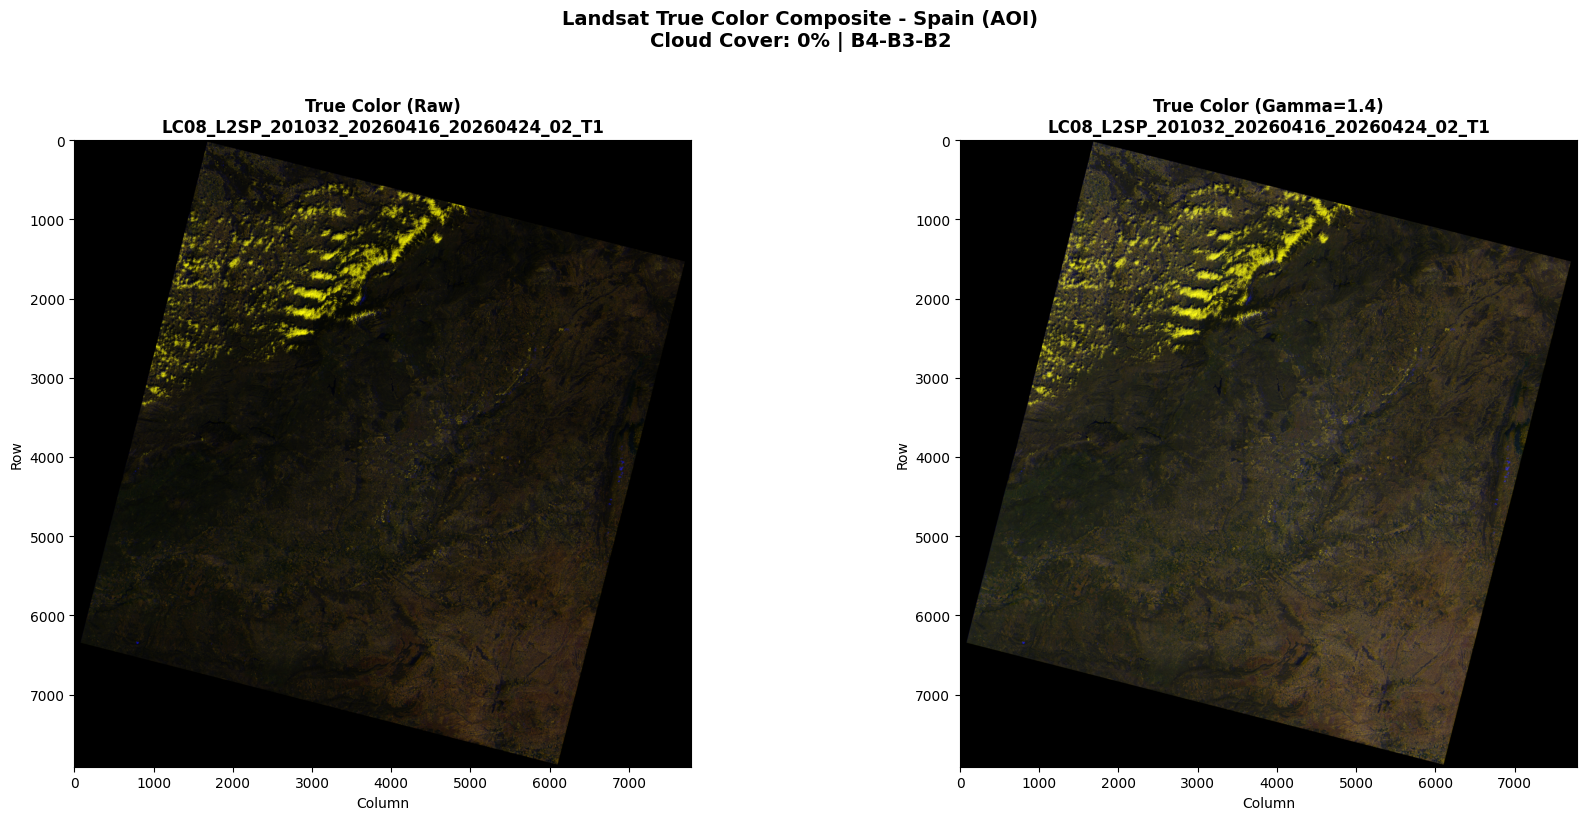

Saved: /teamspace/studios/this_studio/Antigravity/landsat_downloads/true_color_composite.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(rgb)
axes[0].set_title(f'True Color (Raw)\n{display_id}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Column'); axes[0].set_ylabel('Row')

axes[1].imshow(rgb_gamma)
axes[1].set_title(f'True Color (Gamma={gamma})\n{display_id}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Column'); axes[1].set_ylabel('Row')

plt.suptitle(
    f'Landsat True Color Composite - Spain (AOI)\n'
    f'Cloud Cover: {selected_scene.get("cloudCover","N/A")}% | B4-B3-B2',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(DOWNLOAD_DIR, 'true_color_composite.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {os.path.join(DOWNLOAD_DIR, 'true_color_composite.png')}")

## 12. Scene Metadata Summary

In [13]:
print("="*60)
print("SCENE METADATA SUMMARY")
print("="*60)
print(f"  Scene ID    : {display_id}")
print(f"  Entity ID   : {entity_id}")
print(f"  Dataset     : {DATASET_NAME}")
print(f"  Cloud Cover : {selected_scene.get('cloudCover','N/A')}%")
print(f"  Acquisition : {selected_scene.get('temporalCoverage',{}).get('startDate','N/A')}")
print(f"  CRS         : {crs}")
print(f"  Bounds      : {bounds}")
print(f"  Image Size  : {rgb.shape[1]} x {rgb.shape[0]} px")
print(f"  AOI         : Spain (Madrid)")
print(f"  USGS User   : {USGS_USERNAME}")
print("="*60)

SCENE METADATA SUMMARY
  Scene ID    : LC08_L2SP_201032_20260416_20260424_02_T1
  Entity ID   : LC82010322026106LGN00
  Dataset     : landsat_ot_c2_l2
  Cloud Cover : 0%
  Acquisition : 2026-04-16 00:00:00
  CRS         : EPSG:32630
  Bounds      : BoundingBox(left=312585.0, bottom=4345785.0, right=546315.0, top=4583115.0)
  Image Size  : 7791 x 7911 px
  AOI         : Spain (Madrid)
  USGS User   : Rishi_677


## 13. Logout

In [14]:
logout()

Logged out.


---
## 📋 How to Check if Files are Downloading

### Method 1: USGS EarthExplorer Website
1. Go to https://earthexplorer.usgs.gov/
2. Login with `Rishi_677`
3. Click **View Item Basket** (cart icon, top-right)
4. Check **Pending / Download** tab for status

### Method 2: M2M API Check (run cell below)

In [16]:
# Re-login if needed
if api_key is None:
    login()

print("Checking download status via M2M API...\n")
try:
    status = m2m_request("download-retrieve", {"label": download_label})
    if status:
        avail = status.get('available', [])
        pending = status.get('requested', [])
        print(f"Label: {download_label}")
        print(f"  Ready     : {len(avail)}")
        print(f"  Preparing : {len(pending)}")
        for a in avail:
            print(f"    ✓ {a.get('displayId','N/A')}")
        for p in pending:
            print(f"    ⏳ {p.get('displayId','N/A')} - {p.get('statusText','pending')}")
except Exception as e:
    print(f"Error: {e}")

try:
    logout()
except:
    pass

Login successful! API Key: eyJjaWQiOjI3ODk1OTg5...
Checking download status via M2M API...

Label: spain_landsat_20260425_213342
  Ready     : 1
  Preparing : 0
    ✓ LC08_L2SP_201032_20260416_20260424_02_T1
Logged out.


### Method 3: Check Local Files

In [17]:
print(f"Download directory: {DOWNLOAD_DIR}\n")
for root, dirs, files in os.walk(DOWNLOAD_DIR):
    level = root.replace(DOWNLOAD_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files):
        fp = os.path.join(root, f)
        sz = os.path.getsize(fp) / (1024*1024)
        status = "✓" if sz > 0.1 else "⚠"
        print(f"{indent}  [{status}] {f} ({sz:.2f} MB)")

Download directory: /teamspace/studios/this_studio/Antigravity/landsat_downloads

landsat_downloads/
  [✓] LC08_L2SP_201032_20260331_20260407_02_T1.tar (955.21 MB)
  [✓] LC08_L2SP_201032_20260416_20260424_02_T1.tar (956.39 MB)
  [✓] best_unet.pth (29.45 MB)
  [✓] confusion_matrix.png (0.15 MB)
  [✓] confusion_matrix_norm.png (0.13 MB)
  [✓] esri_lulc_10m.tif (8.42 MB)
  [✓] esri_lulc_clipped.tif (8.42 MB)
  [✓] esri_lulc_map.png (0.56 MB)
  [⚠] f1_iou_per_class.png (0.06 MB)
  [✓] hp_tuning.png (0.20 MB)
  [✓] lulc_clipped_comparison.png (1.82 MB)
  [✓] ndvi.tif (135.76 MB)
  [✓] ndvi_map.png (1.71 MB)
  [⚠] predictions.png (0.09 MB)
  [✓] roc_curves.png (0.22 MB)
  [✓] train_test_patches.png (1.69 MB)
  [✓] training_curves.png (0.12 MB)
  [✓] true_color_composite.png (2.25 MB)
  extracted/
    [✓] LC08_L2SP_201032_20260331_20260407_02_T1_ANG.txt (0.11 MB)
    [⚠] LC08_L2SP_201032_20260331_20260407_02_T1_MTL.txt (0.01 MB)
    [⚠] LC08_L2SP_201032_20260331_20260407_02_T1_MTL.xml (0.02 M